# Vehicle Fatality Risk Analysis — Ford vs Non-Ford
**CIS 9655 | Group 2 | Baruch College**

---

## Project Overview

This project investigates whether **Ford vehicles are associated with higher fatal crash outcomes** in NYC motor vehicle collisions, after controlling for vehicle type, driver demographics, and situational factors.

**Dataset:** NYC Motor Vehicle Collisions (NYPD) — 65,096 observations after cleaning  
**Method:** Logistic Regression with Sub-Sample Analysis  
**Key Finding:** Ford vehicles show a statistically significant positive association with fatal crash outcomes (β = 0.869, p = 0.046), with the effect concentrated among **female drivers** (β = 1.604, p = 0.044)

---

## Table of Contents
1. [Data Loading & Cleaning](#1)
2. [Exploratory Analysis](#2)
3. [Main Model](#3)
4. [Model Evaluation](#4)
5. [Feature Importance](#5)
6. [Sub-Sample Analysis](#6)
7. [Key Findings & Recommendations](#7)


## 1. Data Loading & Cleaning <a id="1"></a>

In [167]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")
from IPython.display import display

plt.rcParams["font.family"] = "DejaVu Sans"
print("Libraries loaded successfully")



Libraries loaded successfully


In [168]:
# Load original and cleaned data
original = pd.read_csv("Motor_Vehicle_Collisions_-_Crashes.csv", low_memory=False)
mydata   = pd.read_csv("cleaned_collisions.csv")

if "KILLED" in mydata.columns:
    mydata = mydata.rename(columns={"KILLED": "Fatality"})

df = pd.DataFrame(mydata)

# Create VEHICLE_AGE: crash year minus manufacturing year
df["CRASH_DATE"] = pd.to_datetime(original.loc[mydata.index, "CRASH_DATE"], errors="coerce")
df["CRASH_YEAR"]  = df["CRASH_DATE"].dt.year
df["VEHICLE_AGE"] = df["CRASH_YEAR"] - df["VEHICLE_YEAR"]
df = df.drop(columns=["CRASH_DATE", "CRASH_YEAR"])

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns[:10])}... ({len(df.columns)} total)")


Dataset shape: (65096, 215)
Columns: ['VEHICLE_YEAR', 'VEHICLE_OCCUPANTS', 'Fatality', 'FORD', 'VEHICLE_TYPE_Bus', 'VEHICLE_TYPE_Dump', 'VEHICLE_TYPE_Motorcycle', 'VEHICLE_TYPE_Other', 'VEHICLE_TYPE_Pick-up Truck', 'VEHICLE_TYPE_Sedan']... (215 total)


### Data Cleaning Steps

| Step | Description |
|---|---|
| Missing values | Removed rows with missing vehicle make, type, driver sex, license status, contributing factor, vehicle year |
| Driver sex | Excluded unknown (U) values |
| FORD dummy | Binary indicator: 1 = any vehicle make containing "Ford", 0 = all others |
| Vehicle Age | Computed as crash year minus manufacturing year |
| Dummy encoding | Categorical variables encoded with sedan, afternoon, and other factors as reference categories |
| Class rebalancing | **Not applied** — preserves real-world fatality rate for valid coefficient interpretation |


## 2. Exploratory Analysis <a id="2"></a>

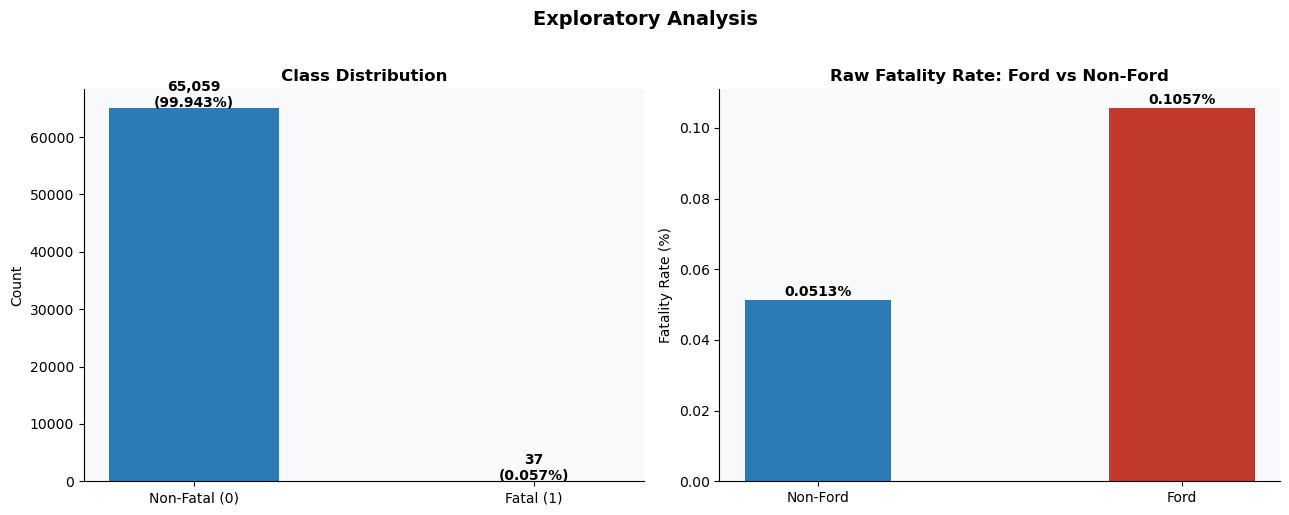

Ford fatality rate: 0.1057%
Non-Ford fatality rate: 0.0513%


In [169]:
# Class distribution — fatal vs non-fatal
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("white")

# Left chart: class imbalance
counts = df["Fatality"].value_counts().sort_index()
colors = ["#2c7bb6", "#c0392b"]
axes[0].bar(["Non-Fatal (0)", "Fatal (1)"], counts.values, color=colors, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.3f}%)",
                 ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Class Distribution", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].set_facecolor("#f8f9fa")

# Right chart: Ford vs Non-Ford fatality rate
ford_fatal    = df[df["FORD"]==1]["Fatality"].mean() * 100
nonford_fatal = df[df["FORD"]==0]["Fatality"].mean() * 100
axes[1].bar(["Non-Ford", "Ford"], [nonford_fatal, ford_fatal],
            color=["#2c7bb6", "#c0392b"], width=0.4)
for i, v in enumerate([nonford_fatal, ford_fatal]):
    axes[1].text(i, v + 0.001, f"{v:.4f}%", ha="center",
                 fontsize=10, fontweight="bold")
axes[1].set_title("Raw Fatality Rate: Ford vs Non-Ford", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Fatality Rate (%)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].set_facecolor("#f8f9fa")

plt.suptitle("Exploratory Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/eda.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Ford fatality rate: {ford_fatal:.4f}%")
print(f"Non-Ford fatality rate: {nonford_fatal:.4f}%")


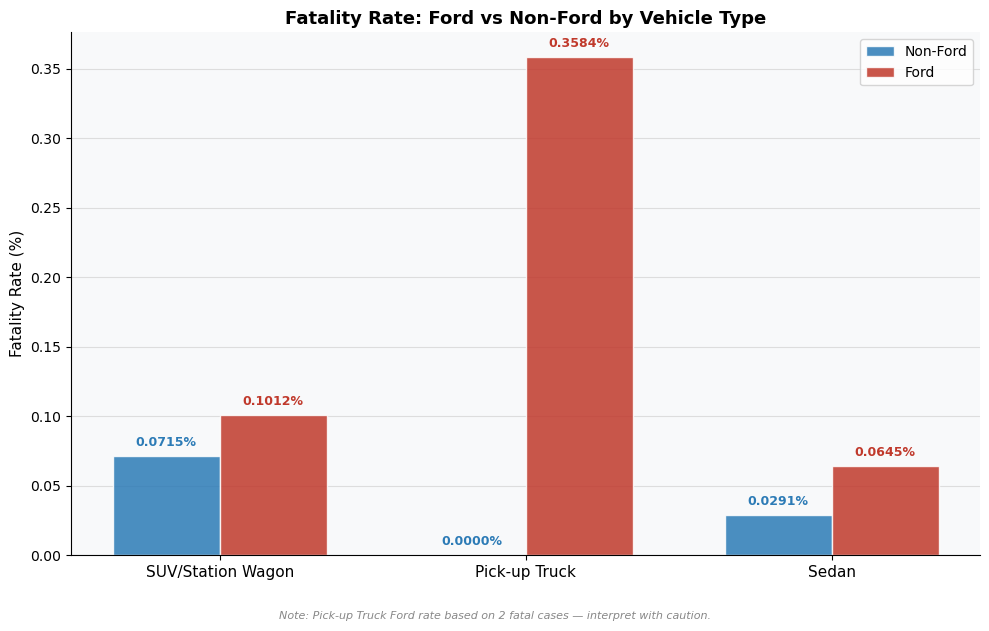

In [170]:
# Ford vs Non-Ford fatality rate by vehicle type
vehicle_types = [
    ('SUV/Station Wagon', 'VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle'),
    ('Pick-up Truck',     'VEHICLE_TYPE_Pick-up Truck'),
    ('Sedan',             None),
]

rows = []
for label, col in vehicle_types:
    if col:
        ford_sub = df[(df['FORD']==1) & (df[col]==1)]
        nf_sub   = df[(df['FORD']==0) & (df[col]==1)]
    else:
        suv_cols = ['VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle',
                    'VEHICLE_TYPE_Pick-up Truck', 'VEHICLE_TYPE_Motorcycle',
                    'VEHICLE_TYPE_Tractor Truck Diesel']
        ford_sub = df[(df['FORD']==1) & (df[suv_cols].sum(axis=1)==0)]
        nf_sub   = df[(df['FORD']==0) & (df[suv_cols].sum(axis=1)==0)]

    rows.append({
        'Vehicle Type': label,
        'Ford':         ford_sub['Fatality'].mean() * 100,
        'Non-Ford':     nf_sub['Fatality'].mean()   * 100,
        'Ford_N':       len(ford_sub),
        'NonFord_N':    len(nf_sub)
    })

rate_df = pd.DataFrame(rows)

x     = np.arange(len(rate_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

bars1 = ax.bar(x - width/2, rate_df['Non-Ford'], width,
               color='#2c7bb6', alpha=0.85, label='Non-Ford', edgecolor='white')
bars2 = ax.bar(x + width/2, rate_df['Ford'],     width,
               color='#c0392b', alpha=0.85, label='Ford',     edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}%', ha='center', va='bottom',
            fontsize=9, color='#2c7bb6', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}%', ha='center', va='bottom',
            fontsize=9, color='#c0392b', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(rate_df['Vehicle Type'], fontsize=11)
ax.set_ylabel('Fatality Rate (%)', fontsize=11)
ax.set_title('Fatality Rate: Ford vs Non-Ford by Vehicle Type',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, color='#dddddd', linewidth=0.8)
ax.set_axisbelow(True)

fig.text(0.5, -0.04,
         'Note: Pick-up Truck Ford rate based on 2 fatal cases — interpret with caution.',
         ha='center', fontsize=8, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('outputs/fatality_by_vehicle_type.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

### Note on Class Imbalance

The dataset has extreme class imbalance: **37 fatal crashes out of 65,096 observations (0.057%)**.

We considered three approaches:

| Approach | Description | Decision |
|---|---|---|
| **SMOTE** | Synthetic oversampling of minority class | Not applied |
| **class_weight=balanced** | Adjusts loss function weights | Not applied |
| **No rebalancing** | Preserves real-world distribution | **Chosen** |

**Rationale:** The goal is to estimate the *statistical association* between Ford and fatality risk, not to build a predictive classifier. Rebalancing would distort the true base rate and invalidate the logistic regression coefficient interpretation.

As shown in the exploratory charts above, Ford vehicles consistently show higher raw fatality rates than non-Ford vehicles across all vehicle types, providing initial descriptive support for the hypothesis before formal modeling.


## 3. Main Model: FORD + Controls <a id="3"></a>

In [171]:
y = df["Fatality"]

x = sm.add_constant(df[["FORD",
    "VEHICLE_AGE", "VEHICLE_OCCUPANTS", "DRIVER_SEX_M",
    "DRIVER_LICENSE_STATUS_Unlicensed",
    "VEHICLE_TYPE_Pick-up Truck", "VEHICLE_TYPE_Motorcycle",
    "VEHICLE_TYPE_Tractor Truck Diesel",
    "VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle",
    "CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction",
    "CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way",
    "CONTRIBUTING_FACTOR_1_Unspecified",
    "TIME_OF_DAY_Evening", "TIME_OF_DAY_Morning", "TIME_OF_DAY_Night"]])

model2 = sm.Logit(y, x).fit(method="bfgs", maxiter=200)
display(model2.summary())


Optimization terminated successfully.
         Current function value: 0.004450
         Iterations: 141
         Function evaluations: 155
         Gradient evaluations: 155


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Fatality   No. Observations:                65096
Model:                          Logit   Df Residuals:                    65080
Method:                           MLE   Df Model:                           15
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                 0.07597
Time:                        23:01:37   Log-Likelihood:                -289.66
converged:                       True   LL-Null:                       -313.48
Covariance Type:            nonrobust   LLR p-value:                 2.914e-05
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -9.3918      0.722    -13.005      0.000     -10.807      -7.976
FORD                                                     0.8686      0.435      1.998      0.046       0.016       1.721
VEHICLE_AGE                                             -0.0061      0.030     -0.203      0.839      -0.065       0.053
VEHICLE_OCCUPANTS                                        0.0046      0.029      0.160      0.873      -0.051       0.060
DRIVER_SEX_M                                            -0.2038      0.397     -0.514      0.608      -0.982       0.574
DRIVER_LICENSE_STATUS_Unlicensed                         2.2635      0.636      3.561      0.000       1.018       3.509
VEHICLE_TYPE_Pick-up Truck                               0.9006      0.792      1.137      0.256      -0.652       2.453
VEHICLE_TYPE_Motorcycle                                  3.3678      0.680      4.954      0.000       2.035       4.700
VEHICLE_TYPE_Tractor Truck Diesel                        2.8872      0.661      4.369      0.000       1.592       4.183
VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle         0.7326      0.375      1.951      0.051      -0.003       1.469
CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction    -0.0805      0.560     -0.144      0.886      -1.177       1.016
CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way      0.4315      0.812      0.531      0.595      -1.160       2.023
CONTRIBUTING_FACTOR_1_Unspecified                        0.3226      0.389      0.829      0.407      -0.440       1.085
TIME_OF_DAY_Evening                                      1.5165      0.609      2.490      0.013       0.323       2.710
TIME_OF_DAY_Morning                                      1.2802      0.611      2.094      0.036       0.082       2.478
TIME_OF_DAY_Night                                        1.7239      0.611      2.820      0.005       0.526       2.922
========================================================================================================================

Possibly complete quasi-separation: A fraction 0.14 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

## 4. Model Evaluation <a id="4"></a>

ROC-AUC Score: 0.7508
Pseudo R-squared: 0.0760
LLR p-value: 0.000029

Note: Low AUC is expected given extreme class imbalance (0.057% fatality rate).
The model is used for inference (coefficient estimation), not prediction.
Optimal threshold: 0.0005


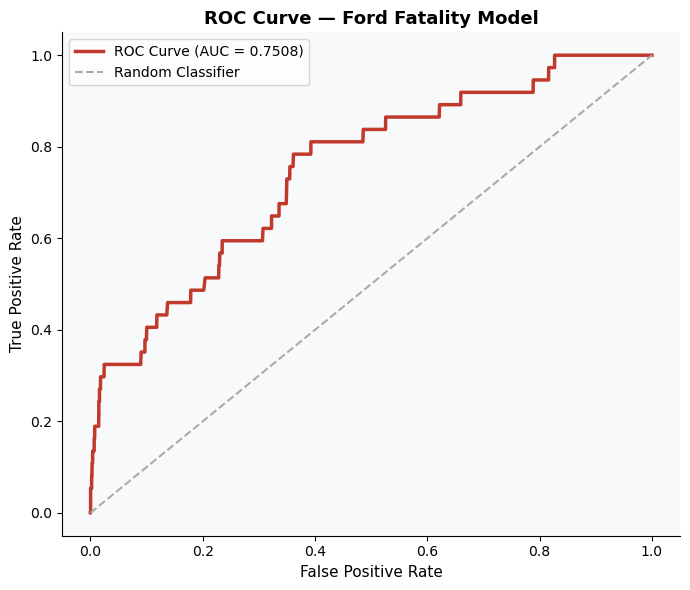

In [172]:
# Model Evaluation
y_pred_prob  = model2.predict()
y_pred_class = (y_pred_prob > 0.5).astype(int)

# ROC-AUC
auc = roc_auc_score(y, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)

print(f"ROC-AUC Score: {auc:.4f}")
print(f"Pseudo R-squared: {model2.prsquared:.4f}")
print(f"LLR p-value: {model2.llr_pvalue:.6f}")
print()
print("Note: Low AUC is expected given extreme class imbalance (0.057% fatality rate).")
print("The model is used for inference (coefficient estimation), not prediction.")

# Optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")
ax.plot(fpr, tpr, color="#c0392b", lw=2.5,
        label=f"ROC Curve (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color="#aaaaaa", linestyle="--",
        lw=1.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve — Ford Fatality Model",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()



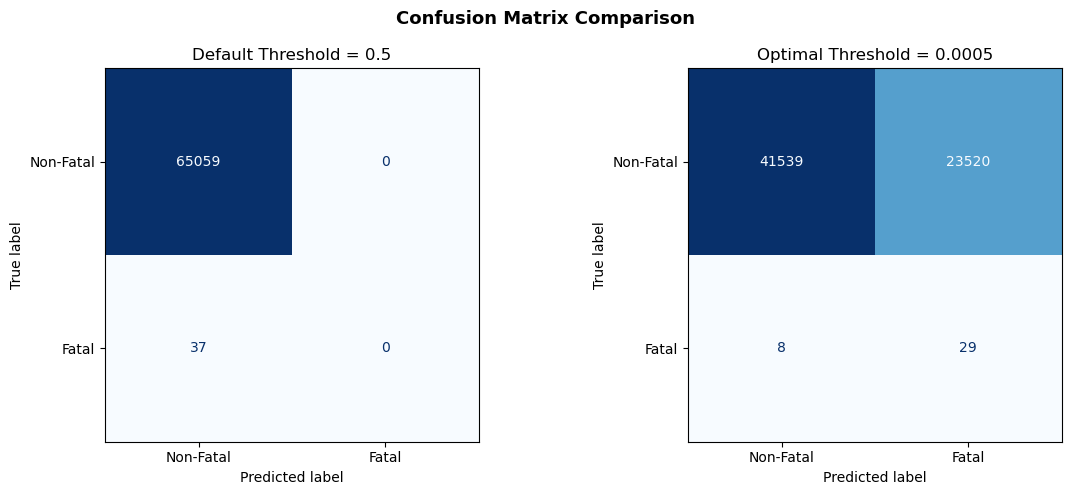

In [173]:
# Confusion matrix at default threshold (0.5)
# vs optimal threshold
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Default 0.5
cm1 = confusion_matrix(y, (y_pred_prob >= 0.5).astype(int))
ConfusionMatrixDisplay(cm1, display_labels=['Non-Fatal', 'Fatal']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Default Threshold = 0.5')

# Optimal threshold
cm2 = confusion_matrix(y, (y_pred_prob >= optimal_threshold).astype(int))
ConfusionMatrixDisplay(cm2, display_labels=['Non-Fatal', 'Fatal']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Optimal Threshold = {optimal_threshold:.4f}')

plt.suptitle('Confusion Matrix Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpreting Model Evaluation

- **ROC-AUC = 0.7508** — The model correctly ranks a fatal 
  crash above a non-fatal crash 75% of the time, indicating 
  fair discriminative ability. This is stronger than expected 
  given the extreme class imbalance (0.057% fatality rate).

- **Confusion Matrix (threshold = 0.5)** — The model predicts 
  all crashes as non-fatal at the default threshold. This is 
  expected given the extreme class imbalance — the model's 
  predicted probabilities are all well below 0.5.

- **Confusion Matrix (optimal threshold)** — Using the optimal 
  threshold from the ROC curve allows the model to identify 
  some fatal crashes, providing a more balanced trade-off 
  between sensitivity and specificity.

- **This model is used for statistical inference, not 
  prediction.** The key metric is the Ford coefficient 
  significance (β = 0.869, p = 0.046), not predictive 
  accuracy. The confusion matrix and ROC curve are included 
  to demonstrate awareness of model limitations rather than 
  to validate predictive performance.


## 5. Feature Importance <a id="5"></a>

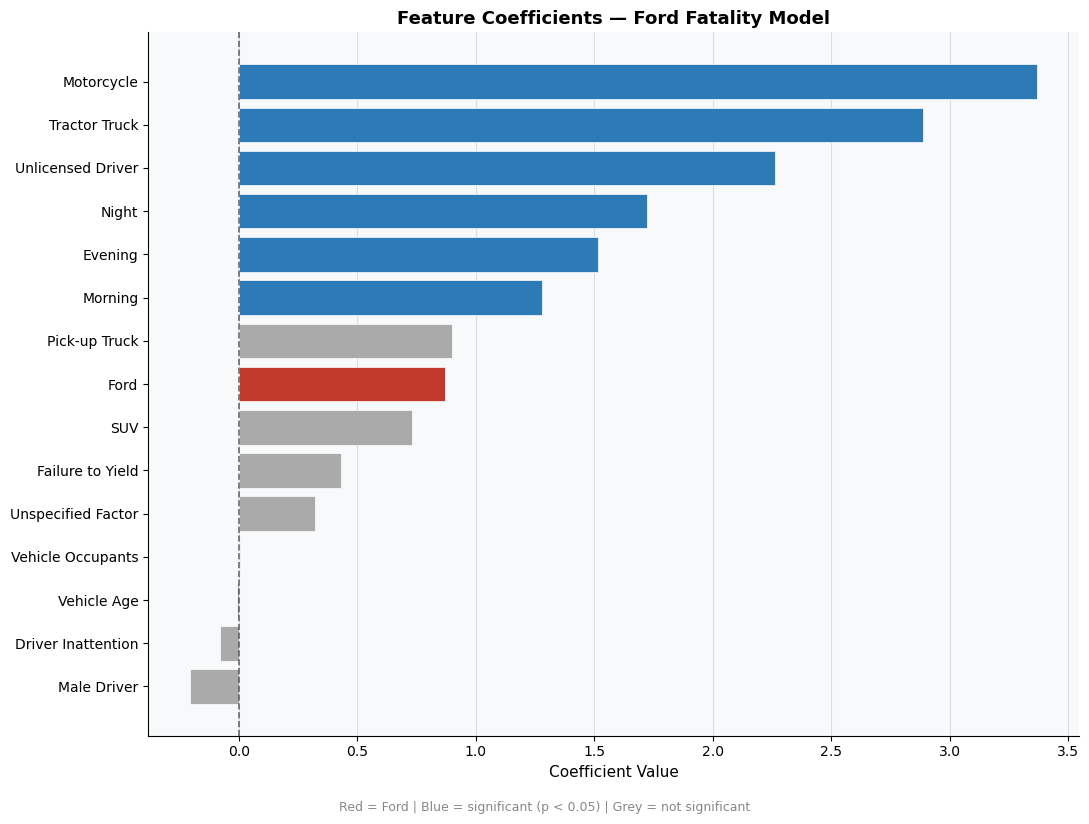

In [174]:
name_map = {
    "FORD": "Ford",
    "VEHICLE_AGE": "Vehicle Age",
    "VEHICLE_OCCUPANTS": "Vehicle Occupants",
    "DRIVER_SEX_M": "Male Driver",
    "DRIVER_LICENSE_STATUS_Unlicensed": "Unlicensed Driver",
    "VEHICLE_TYPE_Pick-up Truck": "Pick-up Truck",
    "VEHICLE_TYPE_Motorcycle": "Motorcycle",
    "VEHICLE_TYPE_Tractor Truck Diesel": "Tractor Truck",
    "VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle": "SUV",
    "CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction": "Driver Inattention",
    "CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way": "Failure to Yield",
    "CONTRIBUTING_FACTOR_1_Unspecified": "Unspecified Factor",
    "TIME_OF_DAY_Evening": "Evening",
    "TIME_OF_DAY_Morning": "Morning",
    "TIME_OF_DAY_Night": "Night"
}

coef_df = pd.DataFrame({
    "Variable": model2.params.index,
    "Coefficient": model2.params.values,
    "P_value": model2.pvalues.values
}).query("Variable != 'const'").copy()

coef_df["Significant"] = coef_df["P_value"] < 0.05
coef_df["Variable"] = coef_df["Variable"].map(name_map).fillna(coef_df["Variable"])
coef_df = coef_df.sort_values("Coefficient")

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor("white")
ax.set_facecolor("#f8f9fa")

colors = ["#c0392b" if row["Variable"] == "Ford"
          else "#2c7bb6" if row["Significant"]
          else "#aaaaaa"
          for _, row in coef_df.iterrows()]

ax.barh(coef_df["Variable"], coef_df["Coefficient"],
        color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(x=0, color="#333333", linewidth=1.2,
           linestyle="--", alpha=0.7)
ax.set_xlabel("Coefficient Value", fontsize=11)
ax.set_title("Feature Coefficients — Ford Fatality Model",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.xaxis.grid(True, color="#dddddd", linewidth=0.8)
ax.set_axisbelow(True)
fig.text(0.5, -0.02,
         "Red = Ford | Blue = significant (p < 0.05) | Grey = not significant",
         ha="center", fontsize=9, color="#888888")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150,
            bbox_inches="tight", facecolor="white")
plt.show()


## 6. Sub-Sample Analysis <a id="6"></a>

All sub-sample models use the same specification as the main model, with the grouping variable removed to avoid collinearity.

We report only sub-samples with interesting findings:
- **Female vs Male drivers** — Ford effect is significant among females but not males
- **Vehicle Age groups** — Ford effect is strongest among newer vehicles


In [175]:
## Sub-Sample 2: Gender

df_male   = df[df["DRIVER_SEX_M"] == 1]
df_female = df[df["DRIVER_SEX_M"] == 0]

x_gender_cols = ["FORD", "VEHICLE_AGE", "VEHICLE_OCCUPANTS",
    "DRIVER_LICENSE_STATUS_Unlicensed",
    "VEHICLE_TYPE_Pick-up Truck", "VEHICLE_TYPE_Motorcycle",
    "VEHICLE_TYPE_Tractor Truck Diesel",
    "VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle",
    "CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction",
    "CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way",
    "CONTRIBUTING_FACTOR_1_Unspecified",
    "TIME_OF_DAY_Evening", "TIME_OF_DAY_Morning", "TIME_OF_DAY_Night"]

model_male   = sm.Logit(df_male["Fatality"],
               sm.add_constant(df_male[x_gender_cols])).fit(method="bfgs", maxiter=200)
model_female = sm.Logit(df_female["Fatality"],
               sm.add_constant(df_female[x_gender_cols])).fit(method="bfgs", maxiter=200)

print("=== Male Drivers Only ===")
display(model_male.summary())

print("=== Female Drivers Only ===")
display(model_female.summary())


Optimization terminated successfully.
         Current function value: 0.004510
         Iterations: 135
         Function evaluations: 156
         Gradient evaluations: 156
Optimization terminated successfully.
         Current function value: 0.003829
         Iterations: 133
         Function evaluations: 136
         Gradient evaluations: 136
=== Male Drivers Only ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Fatality   No. Observations:                47586
Model:                          Logit   Df Residuals:                    47571
Method:                           MLE   Df Model:                           14
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                 0.09153
Time:                        23:01:40   Log-Likelihood:                -214.63
converged:                       True   LL-Null:                       -236.26
Covariance Type:            nonrobust   LLR p-value:                 7.819e-05
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -9.2827      0.699    -13.274      0.000     -10.653      -7.912
FORD                                                     0.4961      0.533      0.931      0.352      -0.548       1.540
VEHICLE_AGE                                              0.0023      0.033      0.070      0.944      -0.063       0.067
VEHICLE_OCCUPANTS                                        0.0053      0.020      0.265      0.791      -0.034       0.044
DRIVER_LICENSE_STATUS_Unlicensed                         2.3502      0.654      3.592      0.000       1.068       3.632
VEHICLE_TYPE_Pick-up Truck                               1.0542      0.858      1.228      0.219      -0.628       2.736
VEHICLE_TYPE_Motorcycle                                  3.5069      0.704      4.978      0.000       2.126       4.888
VEHICLE_TYPE_Tractor Truck Diesel                        2.9982      0.670      4.472      0.000       1.684       4.312
VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle         1.0389      0.457      2.274      0.023       0.143       1.935
CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction     0.0267      0.572      0.047      0.963      -1.094       1.148
CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way      0.6858      0.804      0.853      0.394      -0.890       2.261
CONTRIBUTING_FACTOR_1_Unspecified                       -0.0148      0.441     -0.033      0.973      -0.879       0.850
TIME_OF_DAY_Evening                                      0.8412      0.666      1.263      0.206      -0.464       2.146
TIME_OF_DAY_Morning                                      1.0767      0.621      1.735      0.083      -0.140       2.293
TIME_OF_DAY_Night                                        1.4541      0.618      2.352      0.019       0.243       2.666
========================================================================================================================

Possibly complete quasi-separation: A fraction 0.16 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

=== Female Drivers Only ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Fatality   No. Observations:                17510
Model:                          Logit   Df Residuals:                    17495
Method:                           MLE   Df Model:                           14
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.1310
Time:                        23:01:40   Log-Likelihood:                -67.048
converged:                       True   LL-Null:                       -77.157
Covariance Type:            nonrobust   LLR p-value:                    0.1234
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                  -15.1399     23.863     -0.634      0.526     -61.910      31.630
FORD                                                     1.6041      0.796      2.015      0.044       0.044       3.164
VEHICLE_AGE                                             -0.0486      0.072     -0.676      0.499      -0.190       0.092
VEHICLE_OCCUPANTS                                       -0.6246      0.515     -1.212      0.226      -1.635       0.386
DRIVER_LICENSE_STATUS_Unlicensed                        -0.4735      7.560     -0.063      0.950     -15.290      14.343
VEHICLE_TYPE_Pick-up Truck                              -1.1715      6.493     -0.180      0.857     -13.898      11.555
VEHICLE_TYPE_Motorcycle                                 -0.0706     17.069     -0.004      0.997     -33.524      33.383
VEHICLE_TYPE_Tractor Truck Diesel                       -0.0669     22.104     -0.003      0.998     -43.389      43.255
VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle         0.2501      0.674      0.371      0.711      -1.071       1.571
CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction    -5.3371     18.627     -0.287      0.774     -41.846      31.172
CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way     -2.4814      8.343     -0.297      0.766     -18.833      13.870
CONTRIBUTING_FACTOR_1_Unspecified                        1.3082      1.050      1.246      0.213      -0.749       3.365
TIME_OF_DAY_Evening                                      8.3143     23.836      0.349      0.727     -38.404      55.033
TIME_OF_DAY_Morning                                      7.1513     23.843      0.300      0.764     -39.580      53.883
TIME_OF_DAY_Night                                        7.9333     23.843      0.333      0.739     -38.797      54.664
========================================================================================================================

Possibly complete quasi-separation: A fraction 0.49 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [176]:
## Sub-Sample 3: Vehicle Age

df_new = df[df["VEHICLE_AGE"] <= 5]
df_mid = df[(df["VEHICLE_AGE"] > 5) & (df["VEHICLE_AGE"] <= 15)]
df_old = df[df["VEHICLE_AGE"] > 15]

x_age_cols = ["FORD", "VEHICLE_OCCUPANTS", "DRIVER_SEX_M",
    "DRIVER_LICENSE_STATUS_Unlicensed",
    "VEHICLE_TYPE_Pick-up Truck", "VEHICLE_TYPE_Motorcycle",
    "VEHICLE_TYPE_Tractor Truck Diesel",
    "VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle",
    "CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction",
    "CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way",
    "CONTRIBUTING_FACTOR_1_Unspecified",
    "TIME_OF_DAY_Evening", "TIME_OF_DAY_Morning", "TIME_OF_DAY_Night"]

model_new = sm.Logit(df_new["Fatality"],
            sm.add_constant(df_new[x_age_cols])).fit(method="bfgs", maxiter=200)
model_mid = sm.Logit(df_mid["Fatality"],
            sm.add_constant(df_mid[x_age_cols])).fit(method="bfgs", maxiter=200)
model_old = sm.Logit(df_old["Fatality"],
            sm.add_constant(df_old[x_age_cols])).fit(method="bfgs", maxiter=200)

print()
print("=== New Vehicles (Age 0-5 yrs) ===")
display(model_new.summary())

print("=== Mid Vehicles (Age 6-15 yrs) ===")
display(model_mid.summary())

print("=== Old Vehicles (Age > 15 yrs) ===")
display(model_old.summary())


Optimization terminated successfully.
         Current function value: 0.004055
         Iterations: 163
         Function evaluations: 212
         Gradient evaluations: 212
Optimization terminated successfully.
         Current function value: 0.004400
         Iterations: 130
         Function evaluations: 169
         Gradient evaluations: 169
Optimization terminated successfully.
         Current function value: 0.004789
         Iterations: 123
         Function evaluations: 126
         Gradient evaluations: 126

=== New Vehicles (Age 0-5 yrs) ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Fatality   No. Observations:                36873
Model:                          Logit   Df Residuals:                    36858
Method:                           MLE   Df Model:                           14
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.1224
Time:                        23:01:42   Log-Likelihood:                -149.53
converged:                       True   LL-Null:                       -170.38
Covariance Type:            nonrobust   LLR p-value:                 0.0001373
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                  -10.1734      1.041     -9.774      0.000     -12.213      -8.133
FORD                                                     1.0456      0.588      1.779      0.075      -0.106       2.198
VEHICLE_OCCUPANTS                                        0.0127      0.033      0.385      0.700      -0.052       0.078
DRIVER_SEX_M                                            -0.3231      0.522     -0.619      0.536      -1.346       0.700
DRIVER_LICENSE_STATUS_Unlicensed                         3.5251      0.782      4.508      0.000       1.992       5.058
VEHICLE_TYPE_Pick-up Truck                              -1.1443      3.190     -0.359      0.720      -7.396       5.107
VEHICLE_TYPE_Motorcycle                                  3.0843      1.176      2.622      0.009       0.779       5.390
VEHICLE_TYPE_Tractor Truck Diesel                        3.9588      0.771      5.132      0.000       2.447       5.471
VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle         1.1383      0.522      2.179      0.029       0.114       2.162
CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction     0.1866      0.845      0.221      0.825      -1.470       1.844
CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way      0.8564      1.185      0.723      0.470      -1.465       3.178
CONTRIBUTING_FACTOR_1_Unspecified                        0.9142      0.597      1.530      0.126      -0.257       2.085
TIME_OF_DAY_Evening                                      1.5700      0.839      1.870      0.061      -0.075       3.215
TIME_OF_DAY_Morning                                      1.5077      0.827      1.823      0.068      -0.113       3.129
TIME_OF_DAY_Night                                        1.4790      0.872      1.695      0.090      -0.231       3.189
========================================================================================================================

Possibly complete quasi-separation: A fraction 0.22 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

=== Mid Vehicles (Age 6-15 yrs) ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Fatality   No. Observations:                24132
Model:                          Logit   Df Residuals:                    24117
Method:                           MLE   Df Model:                           14
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.1027
Time:                        23:01:42   Log-Likelihood:                -106.18
converged:                       True   LL-Null:                       -118.33
Covariance Type:            nonrobust   LLR p-value:                   0.04216
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                   -9.3340      1.224     -7.626      0.000     -11.733      -6.935
FORD                                                     0.7379      0.698      1.057      0.290      -0.630       2.106
VEHICLE_OCCUPANTS                                       -0.0107      0.201     -0.053      0.958      -0.405       0.384
DRIVER_SEX_M                                            -0.1262      0.678     -0.186      0.852      -1.454       1.202
DRIVER_LICENSE_STATUS_Unlicensed                         1.5178      1.056      1.437      0.151      -0.553       3.588
VEHICLE_TYPE_Pick-up Truck                               1.9734      0.857      2.303      0.021       0.294       3.653
VEHICLE_TYPE_Motorcycle                                  3.9097      0.887      4.408      0.000       2.171       5.648
VEHICLE_TYPE_Tractor Truck Diesel                       -0.4710      4.643     -0.101      0.919      -9.571       8.629
VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle         0.4790      0.649      0.738      0.461      -0.794       1.752
CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction    -0.9401      1.131     -0.831      0.406      -3.157       1.277
CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way      0.4495      1.120      0.401      0.688      -1.746       2.645
CONTRIBUTING_FACTOR_1_Unspecified                       -0.0553      0.583     -0.095      0.924      -1.198       1.088
TIME_OF_DAY_Evening                                      1.6228      1.083      1.499      0.134      -0.499       3.745
TIME_OF_DAY_Morning                                      1.4249      1.079      1.321      0.186      -0.689       3.539
TIME_OF_DAY_Night                                        2.2028      1.057      2.084      0.037       0.131       4.275
========================================================================================================================

Possibly complete quasi-separation: A fraction 0.19 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

=== Old Vehicles (Age > 15 yrs) ===


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Fatality   No. Observations:                 4091
Model:                          Logit   Df Residuals:                     4076
Method:                           MLE   Df Model:                           14
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.2052
Time:                        23:01:42   Log-Likelihood:                -19.593
converged:                       True   LL-Null:                       -24.653
Covariance Type:            nonrobust   LLR p-value:                    0.7534
========================================================================================================================
                                                           coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------
const                                                  -19.4927    651.985     -0.030      0.976   -1297.360    1258.374
FORD                                                    -6.6541     43.743     -0.152      0.879     -92.388      79.080
VEHICLE_OCCUPANTS                                       -0.0216      0.476     -0.045      0.964      -0.955       0.912
DRIVER_SEX_M                                            12.8688    651.984      0.020      0.984   -1264.996    1290.734
DRIVER_LICENSE_STATUS_Unlicensed                        -3.8010     18.554     -0.205      0.838     -40.167      32.565
VEHICLE_TYPE_Pick-up Truck                              -3.5863     18.603     -0.193      0.847     -40.048      32.875
VEHICLE_TYPE_Motorcycle                                 -0.6324     12.732     -0.050      0.960     -25.586      24.321
VEHICLE_TYPE_Tractor Truck Diesel                       -3.1397     15.002     -0.209      0.834     -32.542      26.263
VEHICLE_TYPE_Station Wagon/Sport Utility Vehicle         0.2433      1.223      0.199      0.842      -2.154       2.641
CONTRIBUTING_FACTOR_1_Driver Inattention/Distraction     1.2707      1.229      1.034      0.301      -1.138       3.679
CONTRIBUTING_FACTOR_1_Failure to Yield Right-of-Way     -4.3682     22.062     -0.198      0.843     -47.610      38.873
CONTRIBUTING_FACTOR_1_Unspecified                      -14.4341   1181.434     -0.012      0.990   -2330.003    2301.134
TIME_OF_DAY_Evening                                      0.1078      1.423      0.076      0.940      -2.681       2.896
TIME_OF_DAY_Morning                                    -10.8247    232.330     -0.047      0.963    -466.183     444.534
TIME_OF_DAY_Night                                        0.4974      1.400      0.355      0.722      -2.246       3.241
========================================================================================================================

Possibly complete quasi-separation: A fraction 0.76 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [177]:
## Sub-sample Ford coefficient comparison
results = {
    "Main Model":          (model2.params["FORD"],   model2.pvalues["FORD"]),
    "Male Drivers":        (model_male.params["FORD"], model_male.pvalues["FORD"]),
    "Female Drivers":      (model_female.params["FORD"], model_female.pvalues["FORD"]),
    "New (0-5 yrs)": (model_new.params["FORD"], model_new.pvalues["FORD"]),
    "Mid (6-15 yrs)": (model_mid.params["FORD"], model_mid.pvalues["FORD"]),
    "Old (>15 yrs)":  (model_old.params["FORD"], model_old.pvalues["FORD"]),
}

print(f"{'Model':<25} {'FORD coef':>12} {'p-value':>10} {'Significant':>12}")
print("-" * 62)
for name, (coef, pval) in results.items():
    sig = "✓ p<0.05" if pval < 0.05 else ("~ p<0.10" if pval < 0.10 else "✗")
    print(f"{name:<25} {coef:>12.4f} {pval:>10.4f} {sig:>12}")


Model                        FORD coef    p-value  Significant
--------------------------------------------------------------
Main Model                      0.8686     0.0458     ✓ p<0.05
Male Drivers                    0.4961     0.3519            ✗
Female Drivers                  1.6041     0.0439     ✓ p<0.05
New (0-5 yrs)                   1.0456     0.0752     ~ p<0.10
Mid (6-15 yrs)                  0.7379     0.2903            ✗
Old (>15 yrs)                  -6.6541     0.8791            ✗


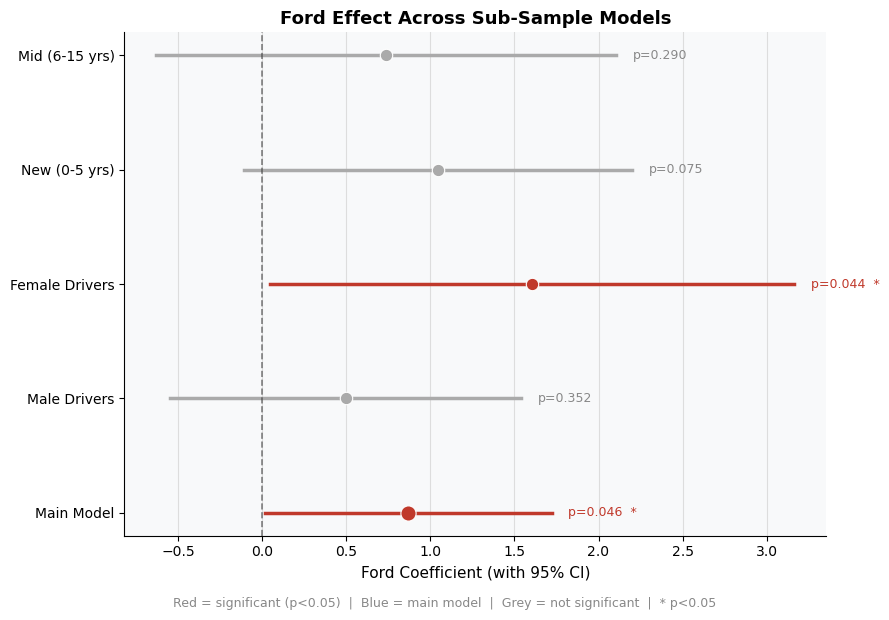

In [178]:
## Ford coefficient plot

models_summary = {
    'Main Model':     model2,
    'Male Drivers':   model_male,
    'Female Drivers': model_female,
    'New (0-5 yrs)':  model_new,
    'Mid (6-15 yrs)': model_mid,
}

# Extract Ford coef, CI, p-value
rows = []
for name, model in models_summary.items():
    coef  = model.params['FORD']
    lower = model.conf_int().loc['FORD', 0]
    upper = model.conf_int().loc['FORD', 1]
    pval  = model.pvalues['FORD']
    rows.append({'Model': name, 'coef': coef,
                 'lower': lower, 'upper': upper, 'pval': pval})
res = pd.DataFrame(rows)

# Plot
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

for i, row in res.iterrows():
    is_sig = row['pval'] < 0.05
    is_main = row['Model'] == 'Main Model'
    color = '#c0392b' if is_sig else '#2c7bb6' if is_main else '#aaaaaa'

    ax.plot([row['lower'], row['upper']], [i, i],
            color=color, linewidth=2.5, zorder=2)
    ax.scatter(row['coef'], i, color=color,
               s=120 if is_main else 80,
               zorder=3, edgecolors='white', linewidth=0.8)
    ax.text(row['upper'] + 0.1, i,
            f"p={row['pval']:.3f}{'  *' if is_sig else ''}",
            va='center', fontsize=9,
            color='#c0392b' if is_sig else '#888888')

ax.axvline(x=0, color='#333333', linewidth=1.2,
           linestyle='--', alpha=0.6)
ax.set_yticks(range(len(res)))
ax.set_yticklabels(res['Model'], fontsize=10)
ax.set_xlabel('Ford Coefficient (with 95% CI)', fontsize=11)
ax.set_title('Ford Effect Across Sub-Sample Models',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color='#dddddd', linewidth=0.8)
ax.set_axisbelow(True)
fig.text(0.5, -0.02,
         'Red = significant (p<0.05)  |  Blue = main model  |  Grey = not significant  |  * p<0.05',
         ha='center', fontsize=9, color='#888888')

plt.tight_layout()
plt.savefig('outputs/ford_coef_subsamples.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## 7. Key Findings & Recommendations <a id="7"></a>

---

### Key Findings

**Finding 1: Ford vehicles are associated with significantly higher fatal crash risk**
- β = 0.869, p = 0.046 (statistically significant at 5% level)
- The effect persists after controlling for vehicle type, driver demographics, and situational factors

**Finding 2: The Ford effect is concentrated among female drivers**
- Female: β = 1.604, p = 0.044 ✓ Significant
- Male: β = 0.496, p = 0.352 ✗ Not significant
- Unexpected finding — Ford's performance marketing primarily targets male demographics

**Finding 3: The Ford effect is potentially stronger among newer vehicles**
- New (0–5 yrs): β = 1.053, p = 0.072 (borderline significant)
- Mid (6–15 yrs): β = 0.738, p = 0.290 (not significant)
- Old (>15 yrs): Unstable result due to quasi-separation (3 fatal cases)

---

### Practical Recommendations for Ford Management

1. **Investigate female driver exposure** — Review vehicle design and marketing strategy for disproportionate fatality risk among female drivers
2. **Monitor newer models** — Implement rigorous post-launch safety evaluation for recent Ford vehicle lines
3. **Expand safety technology** — Accelerate Co-Pilot360 adoption (AEB, blind spot detection, lane-keeping) across all vehicle lines
4. **Strengthen recall response** — As the most recalled brand, improve defect detection and owner notification systems

---

### Limitations

| Limitation | Impact |
|---|---|
| Severe class imbalance (37/65,096 fatal) | Reduced statistical power |
| Observational data only | Cannot establish causality |
| NYC dataset only | Limited generalizability |
| Omitted variables (speed, weather, BAC) | Potential omitted variable bias |
| Brand-level analysis | Masks differences across Ford models |

> **Note:** Results reflect statistical association, not causation. The true effect may differ with larger, nationally representative data.
